<a href="https://colab.research.google.com/github/hdflorez/Entrega_2/blob/main/dataset_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis de Datos | 190304018-1 | 2026-1** | **Entrega 2** |

**Integrantes del equipo:**
*   Mariana Villegas Ochoa
*   Melisa Colorado Soto
*   Jaider Santiago Villa David
*   Hernán Darío Flórez Martínez
---

# **Fase 1: Exploración de Base de datos** | **Dataset 3: Credit Card Fraud Detection** |

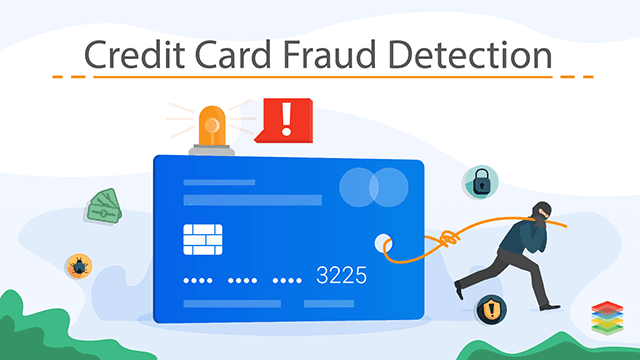

## **Generalidades del dataset**
La detección de transacciones fraudulentas es una necesidad crítica para las entidades emisoras de tarjetas de crédito, con el fin de proteger a los clientes de cargos no autorizados. Este dataset, disponible en Kaggle, reúne transacciones reales realizadas por titulares europeos durante septiembre de 2013, registradas a lo largo de dos días. De un total de 284 807 operaciones, 492 corresponden a fraudes, lo que representa el 0,172 % del total y evidencia un marcado desbalance entre clases. Al haber sido recopilada previamente por una entidad financiera y publicada para análisis, se clasifica como fuente secundaria, presentada en formato tabular (.csv).

Todas las variables son numéricas producto de una transformación PCA aplicada por razones de confidencialidad. Los componentes V1 a V28 corresponden a las variables transformadas, mientras que "Time" y "Amount" conservan su forma original: la primera indica los segundos transcurridos desde la primera transacción del conjunto, y la segunda refleja el monto de cada operación, siendo útil para enfoques de aprendizaje sensible al costo. La variable "Class" es la variable objetivo, con valor 1 para fraude y 0 para transacciones legítimas.

Su documentación es alta, aunque las variables se encuentran anonimizadas. Entre sus aplicaciones destacan la detección de fraude, el desarrollo de modelos de Machine Learning y el análisis de datos desbalanceados. Dado este desbalance, se recomienda evaluar el rendimiento mediante el área bajo la curva de precisión-exhaustividad (AUPRC), ya que métricas convencionales como la exactitud no resultan representativas en este tipo de escenarios. En términos generales, presenta alta completitud, relevancia y documentación, con una manejabilidad media, lo que lo convierte en un recurso muy adecuado para proyectos de clasificación y detección de fraude en contextos reales.

El dataset puede consutlarse en: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

## **Características de dataset**
  * Registros: 284,807
  * Atributos: 31 (28 anonimizados + Time + Amount + Class)
  * Tamaño: ~150 MB
  * Problema: Clasificación binaria (fraude / no fraude)
  * Nota: Datos altamente desbalanceados

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [2]:
# Bloque 1: Importación de librerías y carga de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_palette("husl")

# Ubicación del dataset (archivo descargado de Kaggle)
path_dataset = path + "/creditcard.csv"

# Cargar el dataset
df = pd.read_csv(path_dataset)

# Visualización rápida
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras filas:")
print(df.head())

print("\nInformación general:")
print(df.info())

Dimensiones del dataset: (284807, 31)

Primeras filas:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

Filas: 284807, Columnas: 31


# **Fase 2: Análisis Exploratorio de Datos (EDA)**

In [5]:
# Importación de librerías
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

* 2.1 Revisión de valores faltantes


    
    












Valores nulos por columna:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Porcentaje de valores nulos (%):
Time      0.0
V1        0.0
V2        0.0
V3        0.0
V4        0.0
V5        0.0
V6        0.0
V7        0.0
V8        0.0
V9        0.0
V10       0.0
V11       0.0
V12       0.0
V13       0.0
V14       0.0
V15       0.0
V16       0.0
V17       0.0
V18       0.0
V19       0.0
V20       0.0
V21       0.0
V22       0.0
V23       0.0
V24       0.0
V25       0.0
V26       0.0
V27       0.0
V28       0.0
Amount    0.0
Class     0.0
dtype: float64

Resumen de columnas con valores faltantes:
Empty DataFrame
Columns: [Valores Nulos, Porcentaje (%)]
Inde

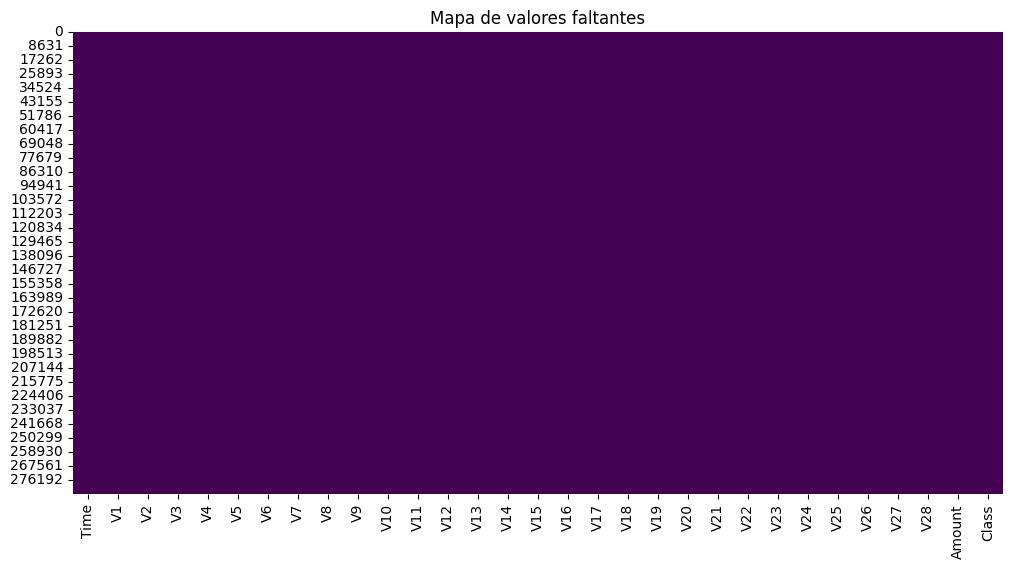

In [6]:
# 1. Conteo de valores nulos por columna
valores_nulos = df.isnull().sum()

print("Valores nulos por columna:")
print(valores_nulos)

# 2. Porcentaje de valores nulos
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100

print("\nPorcentaje de valores nulos (%):")
print(porcentaje_nulos)

# 3. Crear un DataFrame resumen
resumen_nulos = pd.DataFrame({
    'Valores Nulos': valores_nulos,
    'Porcentaje (%)': porcentaje_nulos
})

# Filtrar solo columnas con nulos
resumen_nulos = resumen_nulos[resumen_nulos['Valores Nulos'] > 0]

print("\nResumen de columnas con valores faltantes:")
print(resumen_nulos)

# 4. Visualización (heatmap)
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Mapa de valores faltantes")
plt.show()

In [7]:
#Medidas y tomas de estrategia
resumen = []

for col in df.columns:

    total = len(df)
    nulos = df[col].isnull().sum()
    porcentaje_nulos = (nulos / total) * 100

    tipo = df[col].dtype

    # Medidas solo para numéricas
    if np.issubdtype(tipo, np.number):
        media = df[col].mean()
        mediana = df[col].median()
        moda = df[col].mode()[0] if not df[col].mode().empty else np.nan
        std = df[col].std()
        minimo = df[col].min()
        maximo = df[col].max()
    else:
        media = mediana = std = minimo = maximo = np.nan
        moda = df[col].mode()[0] if not df[col].mode().empty else np.nan

    # Estrategia automática
    if porcentaje_nulos == 0:
        estrategia = "Sin acción"
    elif porcentaje_nulos < 5:
        estrategia = "Imputación (media/mediana/moda)"
    elif porcentaje_nulos < 30:
        estrategia = "Imputación + indicador"
    else:
        estrategia = "Eliminar columna"

    resumen.append({
        "Columna": col,
        "Tipo": tipo,
        "Nulos": nulos,
        "% Nulos": porcentaje_nulos,
        "Media": media,
        "Mediana": mediana,
        "Moda": moda,
        "Std": std,
        "Minimo": minimo,
        "Maximo": maximo,
        "Estrategia Sugerida": estrategia
    })

# Convertir a DataFrame
resumen_df = pd.DataFrame(resumen)

# Mostrar resultados
pd.set_option('display.max_columns', None)
print(resumen_df)


   Columna     Tipo  Nulos  % Nulos         Media       Mediana  \
0     Time  float64      0      0.0  9.481386e+04  84692.000000   
1       V1  float64      0      0.0  1.168375e-15      0.018109   
2       V2  float64      0      0.0  3.416908e-16      0.065486   
3       V3  float64      0      0.0 -1.379537e-15      0.179846   
4       V4  float64      0      0.0  2.074095e-15     -0.019847   
5       V5  float64      0      0.0  9.604066e-16     -0.054336   
6       V6  float64      0      0.0  1.487313e-15     -0.274187   
7       V7  float64      0      0.0 -5.556467e-16      0.040103   
8       V8  float64      0      0.0  1.213481e-16      0.022358   
9       V9  float64      0      0.0 -2.406331e-15     -0.051429   
10     V10  float64      0      0.0  2.239053e-15     -0.092917   
11     V11  float64      0      0.0  1.673327e-15     -0.032757   
12     V12  float64      0      0.0 -1.247012e-15      0.140033   
13     V13  float64      0      0.0  8.190001e-16     -0.01356

* 2.2 Detección de valores atípicos

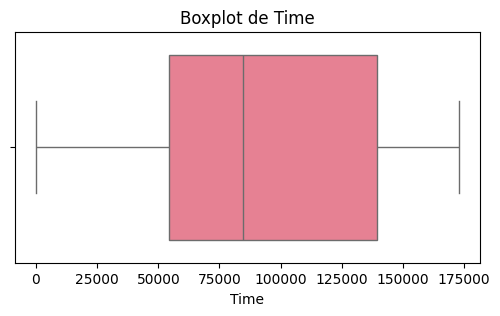

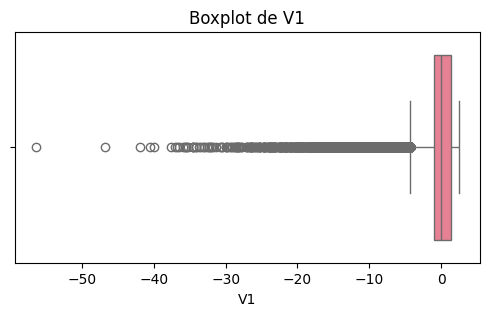

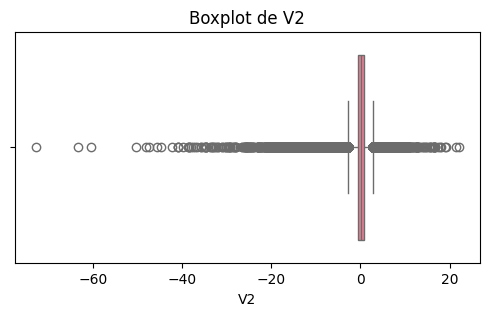

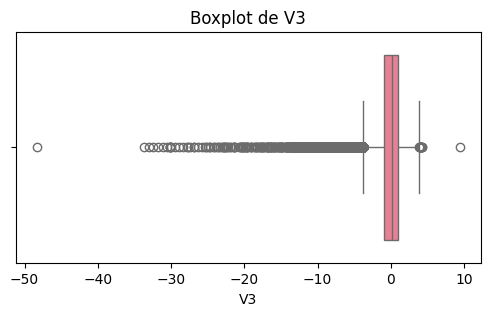

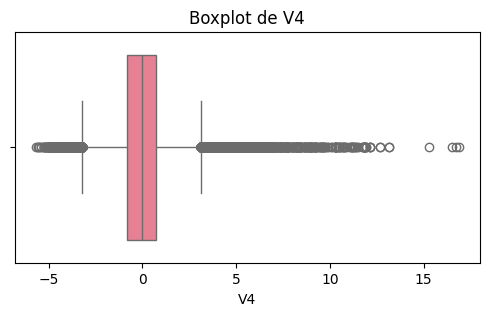

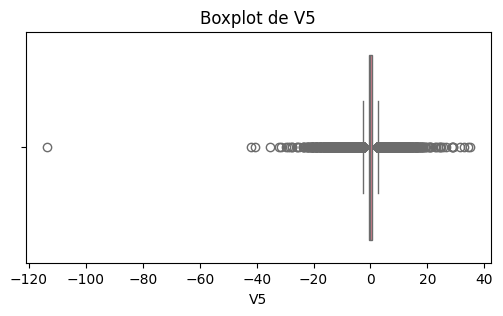

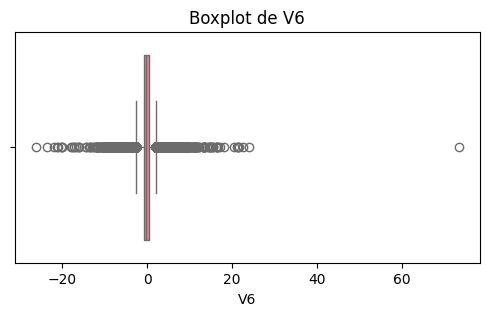

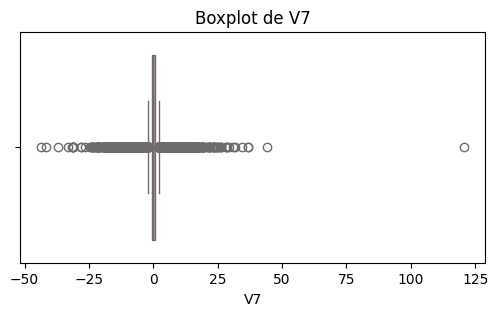

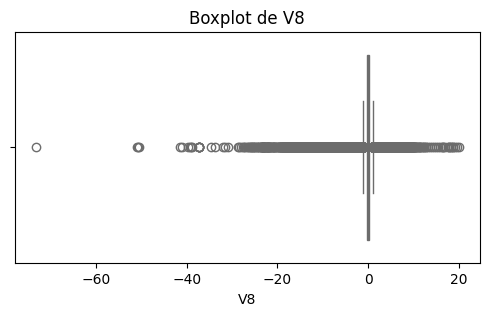

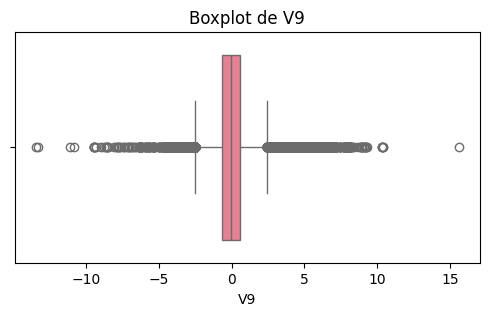

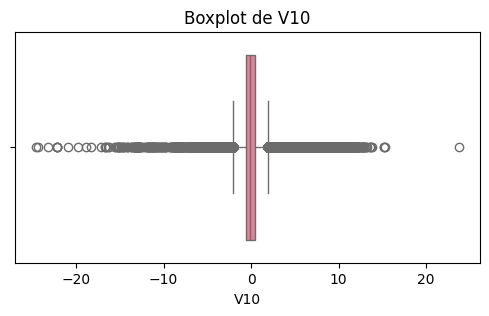

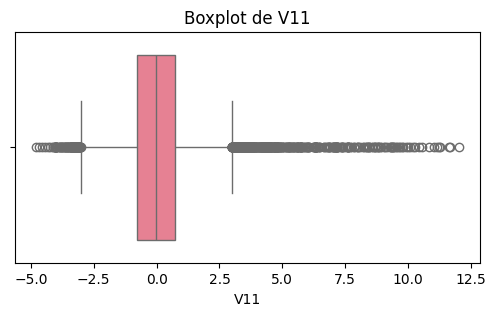

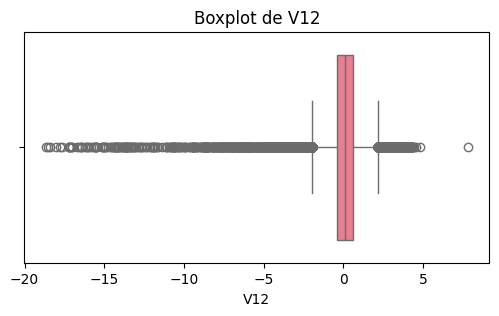

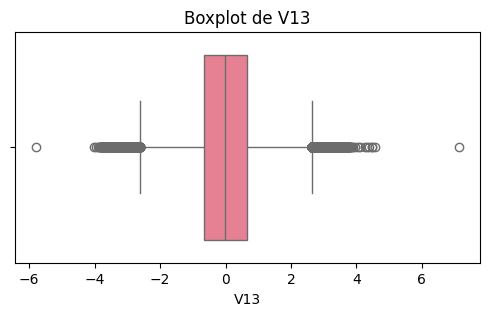

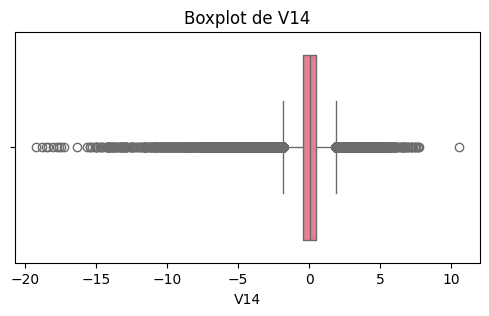

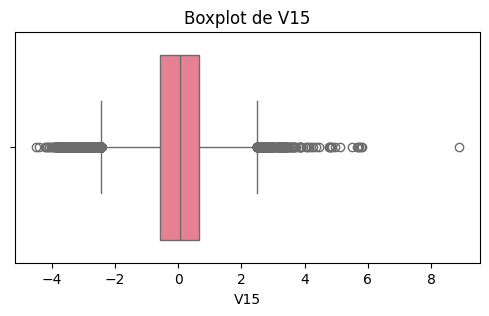

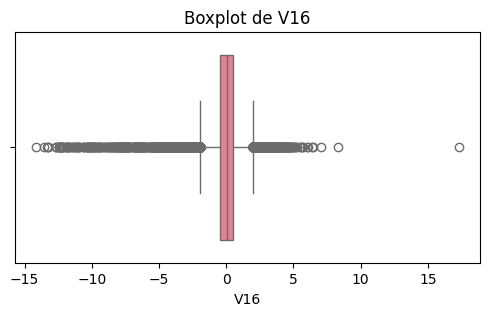

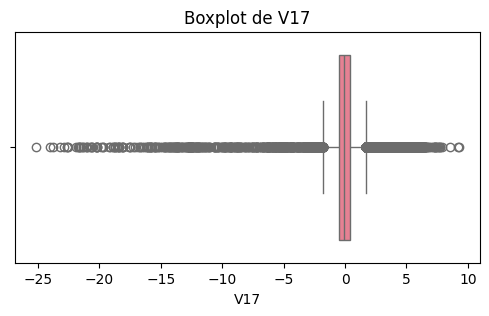

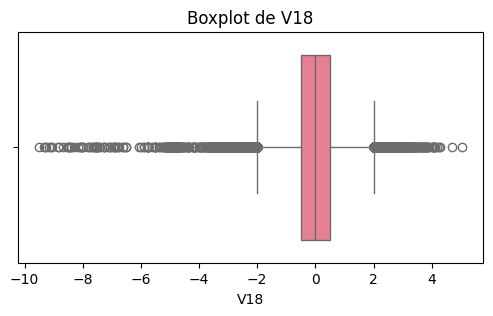

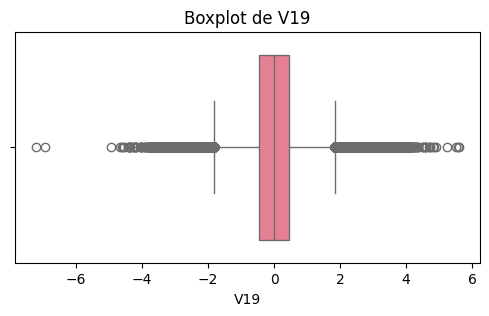

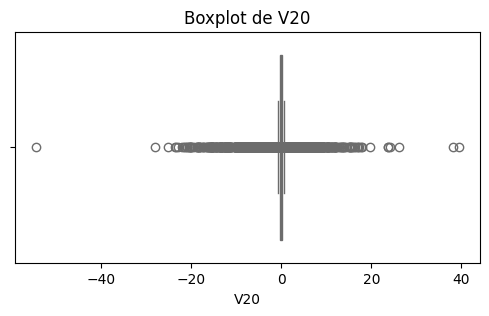

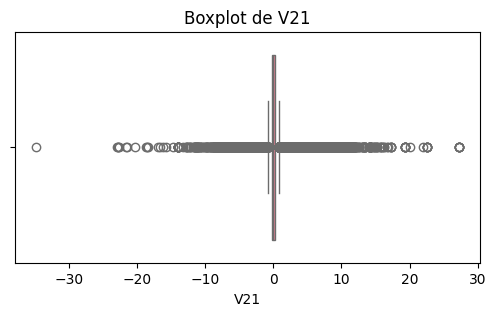

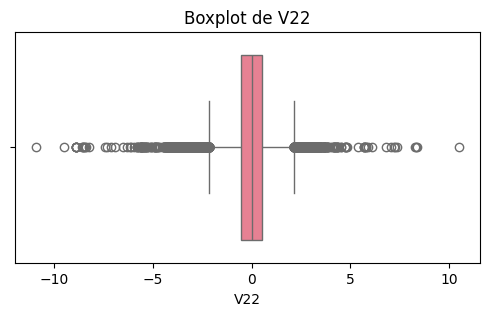

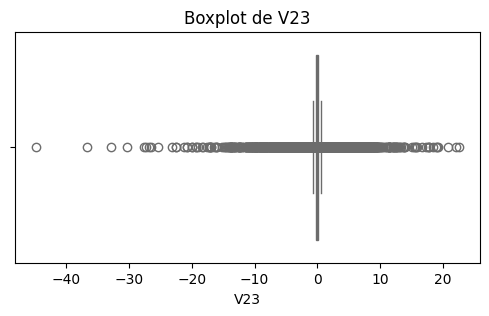

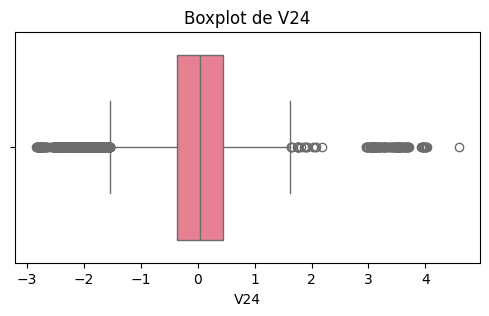

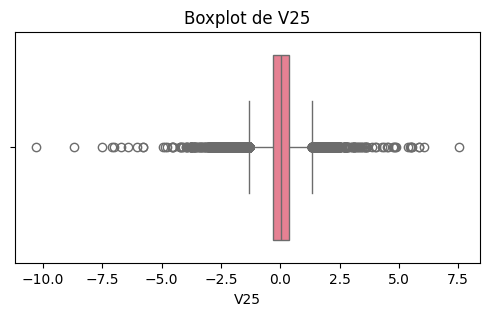

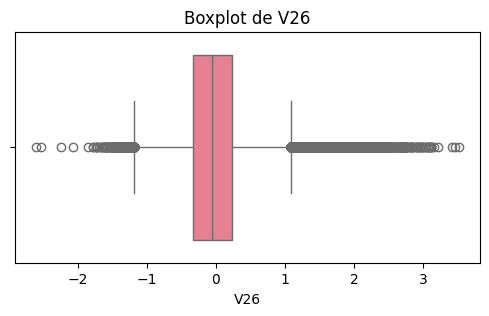

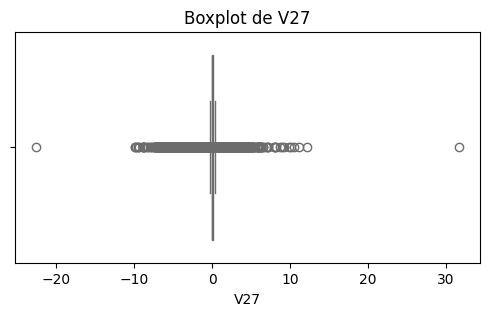

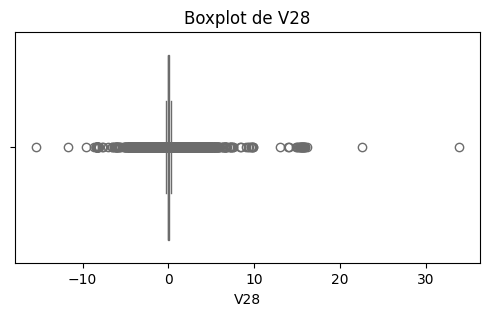

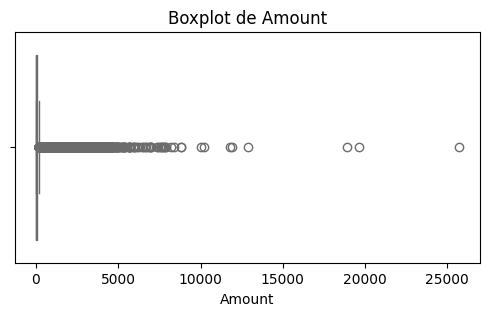

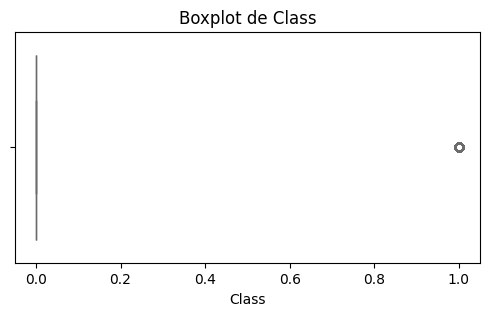

In [8]:
# Boxplots para variables numericas

columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns

for col in columnas_numericas:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

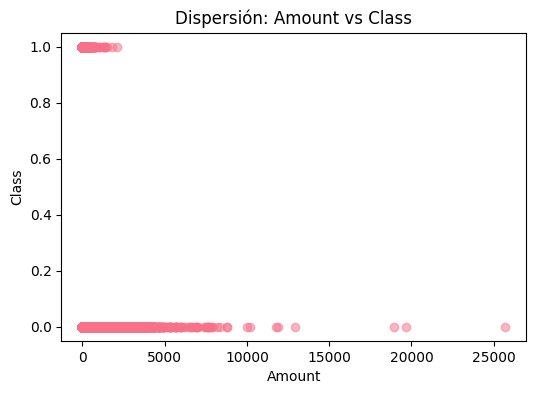

In [9]:
# Scatter plot : Amount vs Class
plt.figure(figsize=(6,4))
plt.scatter(df['Amount'], df['Class'], alpha=0.5)
plt.title("Dispersión: Amount vs Class")
plt.xlabel("Amount")
plt.ylabel("Class")
plt.show()

In [10]:
# Detección de Outliers con IQR

outliers_iqr = {}

for col in columnas_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]

    outliers_iqr[col] = len(outliers)

print("\nCantidad de outliers por columna (IQR):\n")

for col, val in outliers_iqr.items():
    print(f"{col}: {val}")


Cantidad de outliers por columna (IQR):

Time: 0
V1: 7062
V2: 13526
V3: 3363
V4: 11148
V5: 12295
V6: 22965
V7: 8948
V8: 24134
V9: 8283
V10: 9496
V11: 780
V12: 15348
V13: 3368
V14: 14149
V15: 2894
V16: 8184
V17: 7420
V18: 7533
V19: 10205
V20: 27770
V21: 14497
V22: 1317
V23: 18541
V24: 4774
V25: 5367
V26: 5596
V27: 39163
V28: 30342
Amount: 31904
Class: 492


In [11]:
# Detección de Outliers con Z-score

z_scores = np.abs(zscore(df[columnas_numericas]))
outliers_z = (z_scores > 3).sum(axis=0)

print("Outliers por columna (Z-score > 3):\n")

for col, val in zip(columnas_numericas, outliers_z):
    print(f"{col}: {val}")

Outliers por columna (Z-score > 3):

Time: 0
V1: 3701
V2: 4318
V3: 1987
V4: 3094
V5: 2945
V6: 4652
V7: 3401
V8: 4221
V9: 2293
V10: 3488
V11: 684
V12: 3393
V13: 1192
V14: 3380
V15: 1254
V16: 2077
V17: 2515
V18: 1685
V19: 3399
V20: 4645
V21: 4064
V22: 1222
V23: 3364
V24: 657
V25: 2809
V26: 1047
V27: 4771
V28: 3264
Amount: 4076
Class: 492


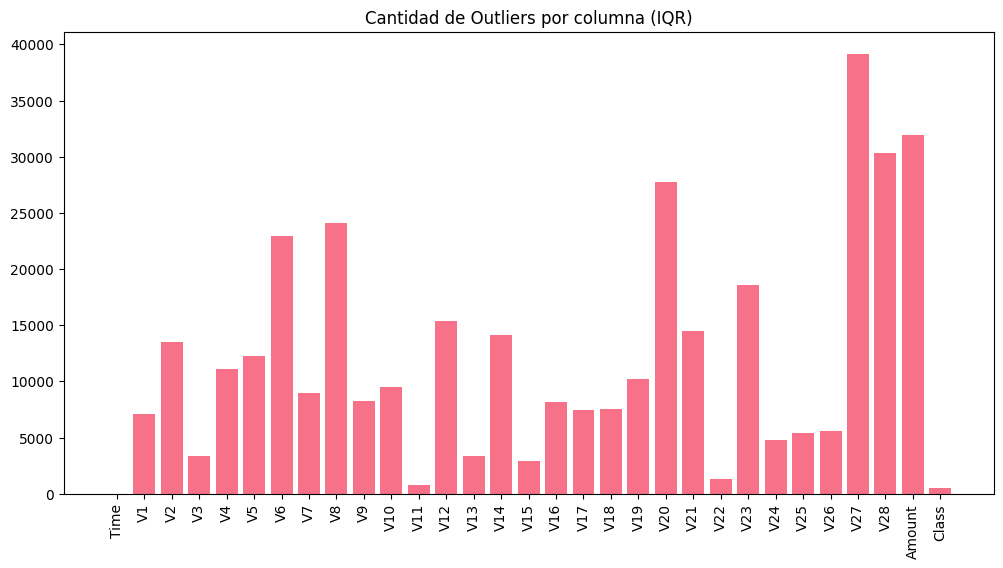

In [12]:
# Convertir resultados IQR a DataFrame
df_outliers = pd.DataFrame(list(outliers_iqr.items()), columns=['Columna', 'Outliers'])

plt.figure(figsize=(12,6))
plt.bar(df_outliers['Columna'], df_outliers['Outliers'])
plt.xticks(rotation=90)
plt.title("Cantidad de Outliers por columna (IQR)")
plt.show()

* 2.3 Análisis de distribuciones

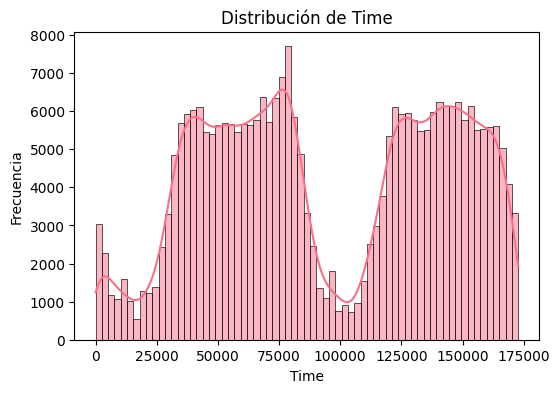

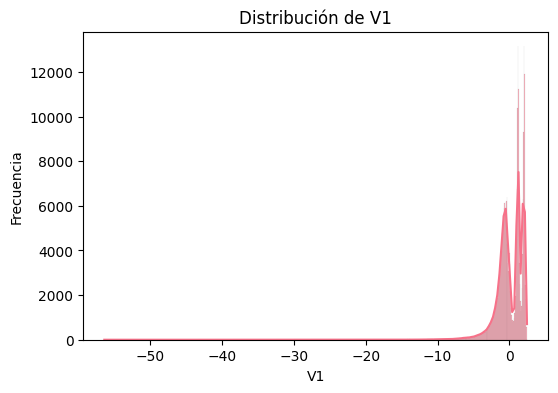

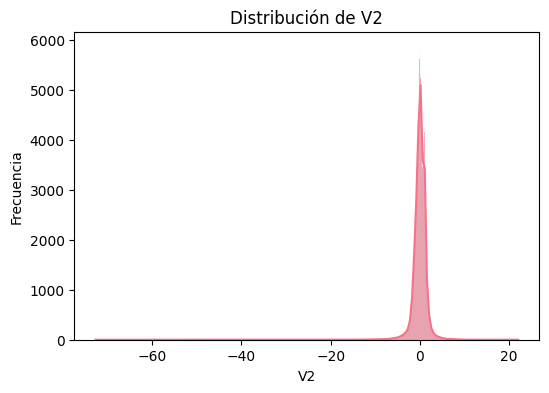

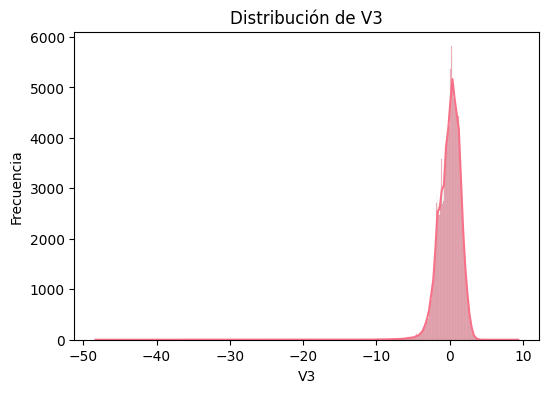

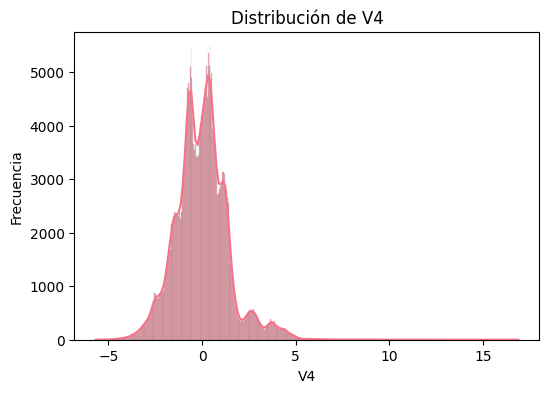

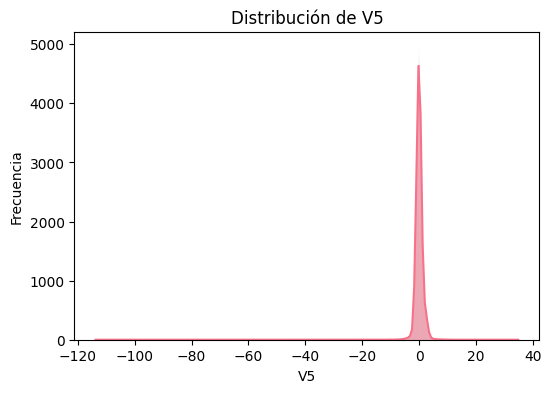

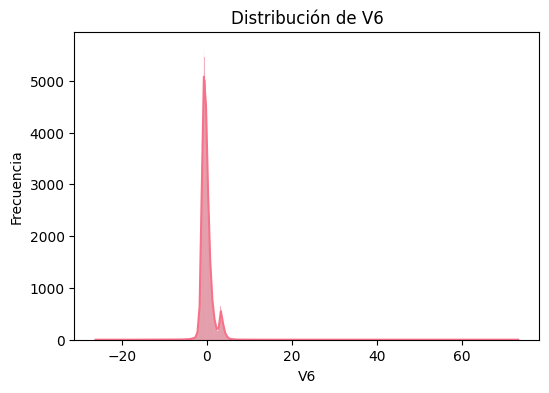

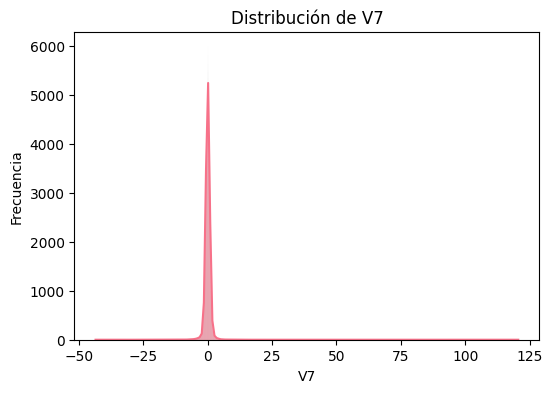

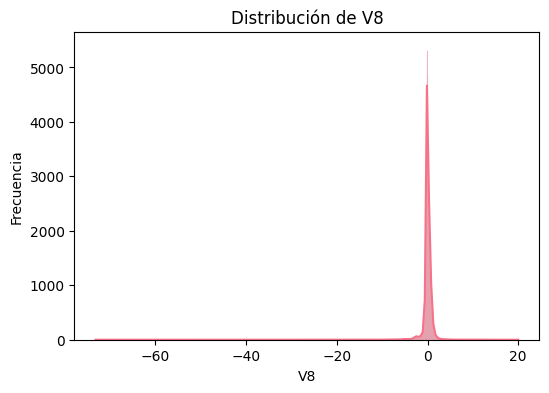

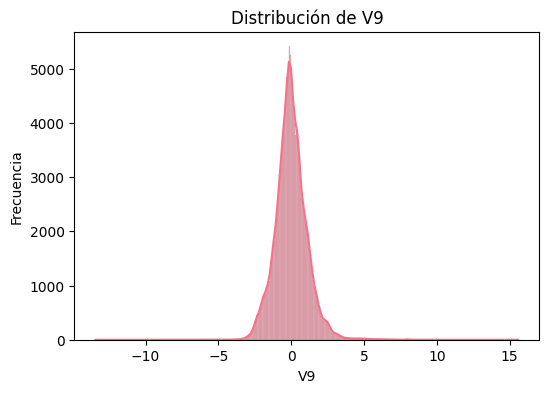

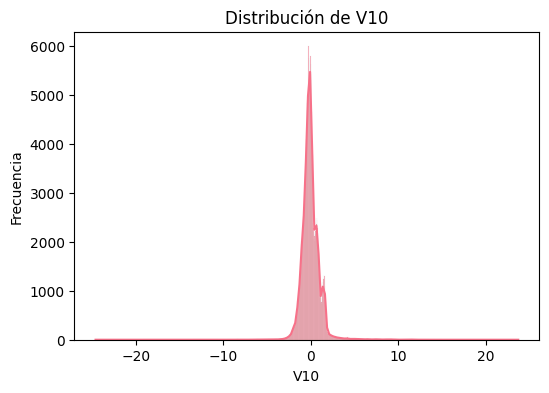

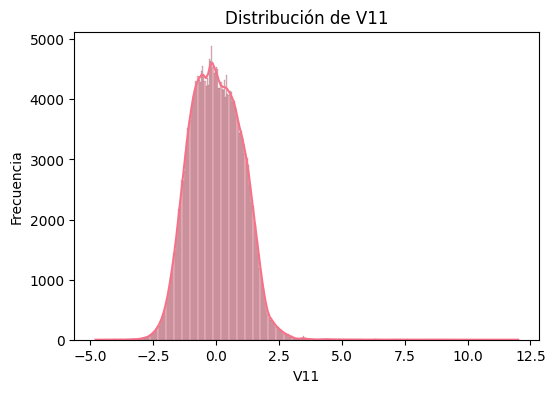

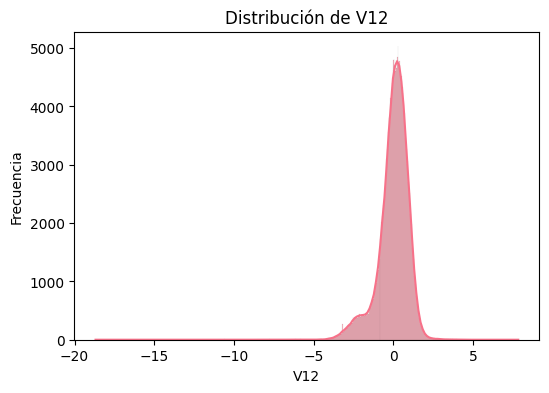

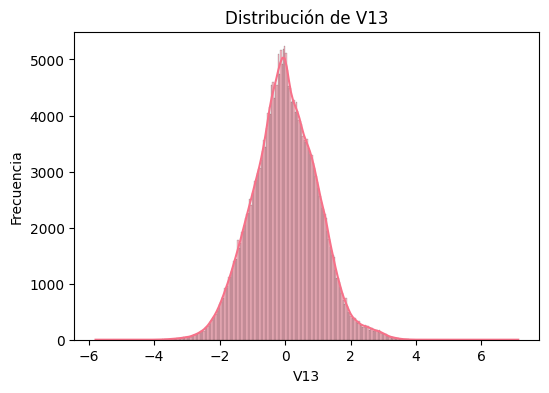

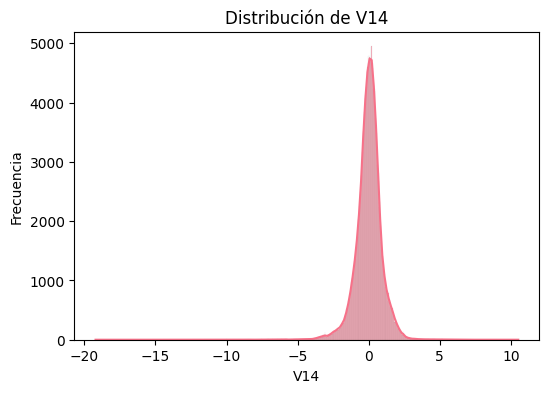

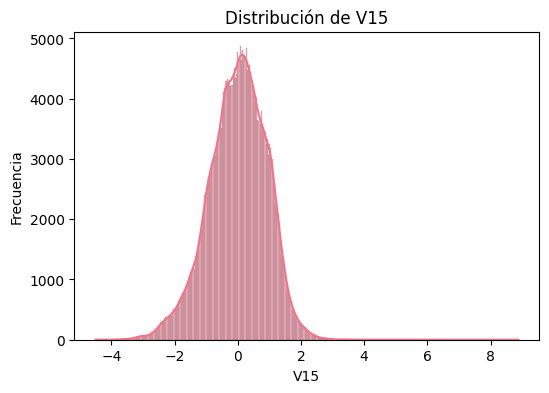

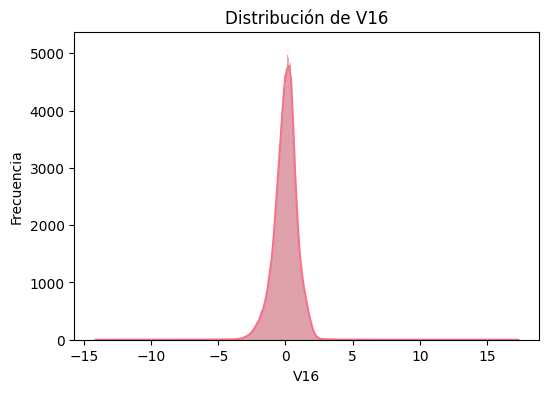

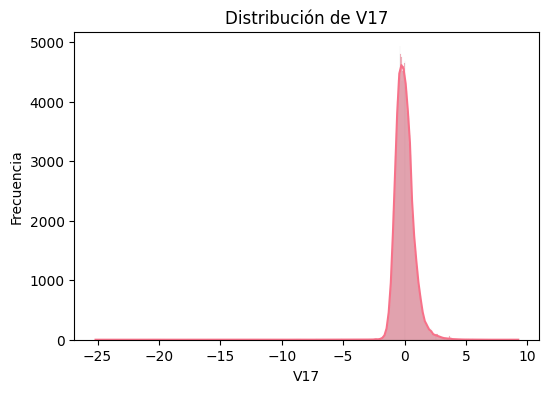

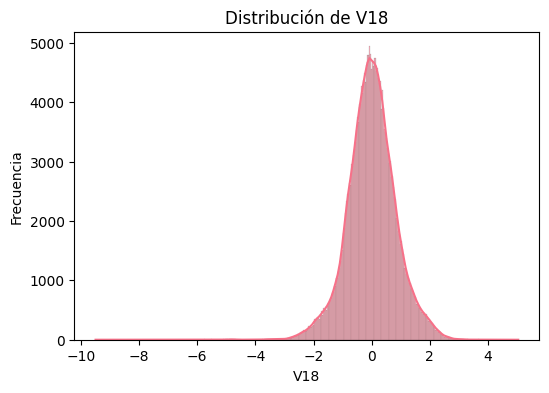

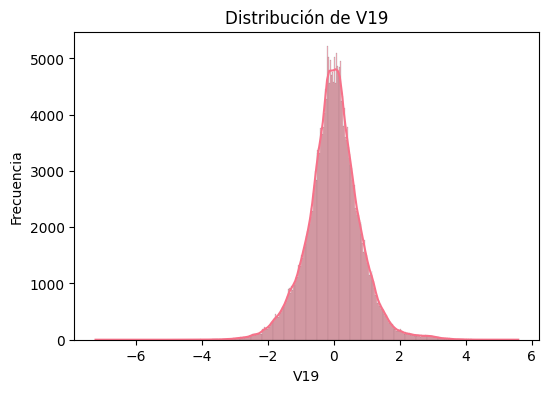

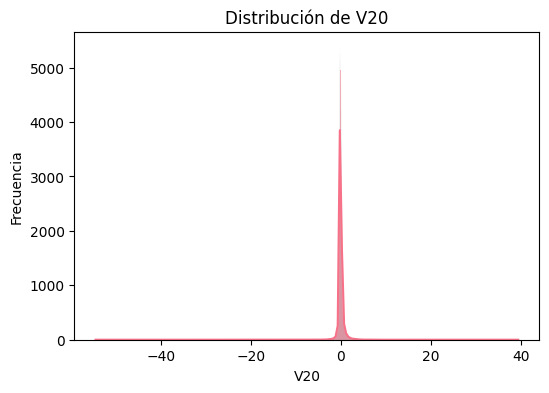

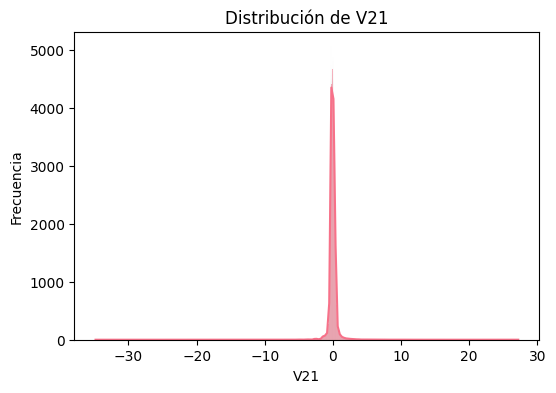

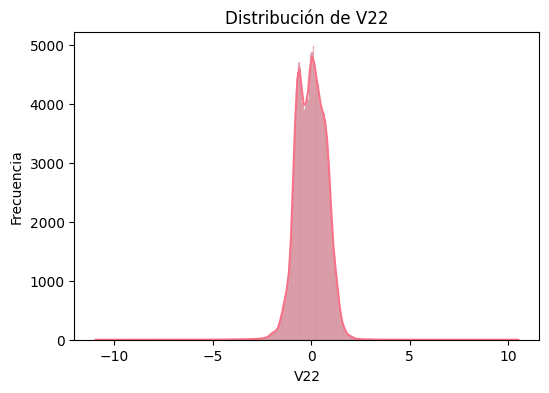

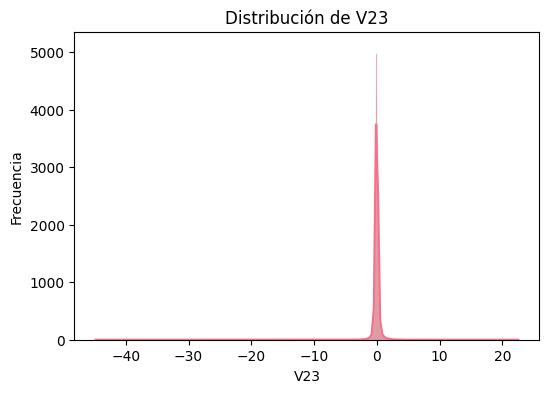

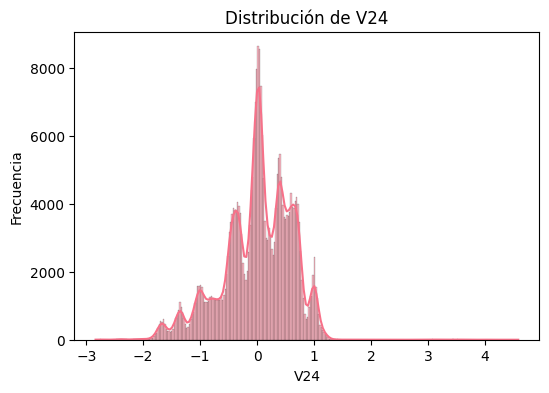

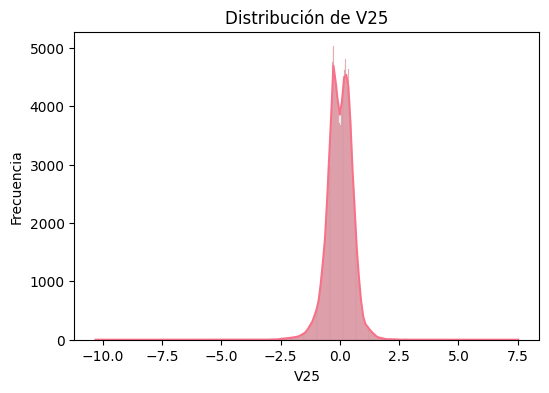

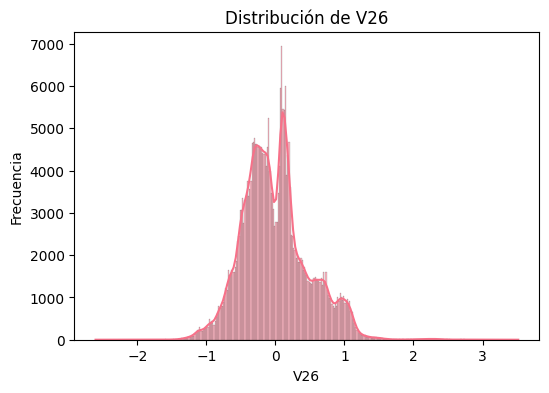

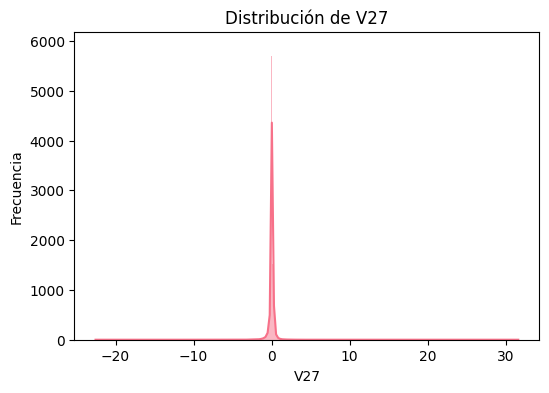

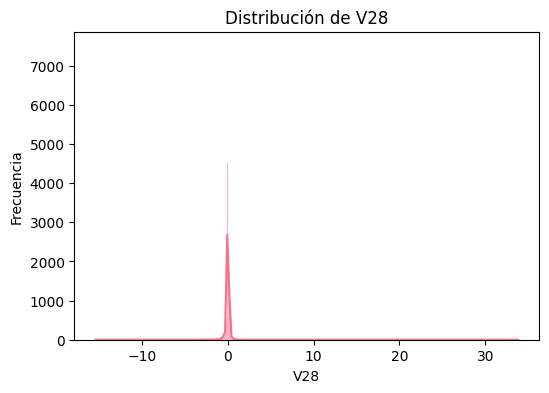

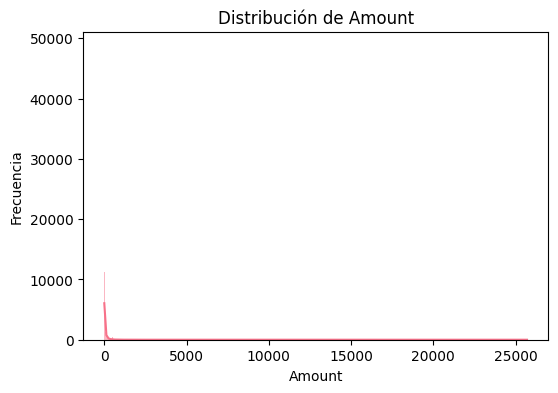

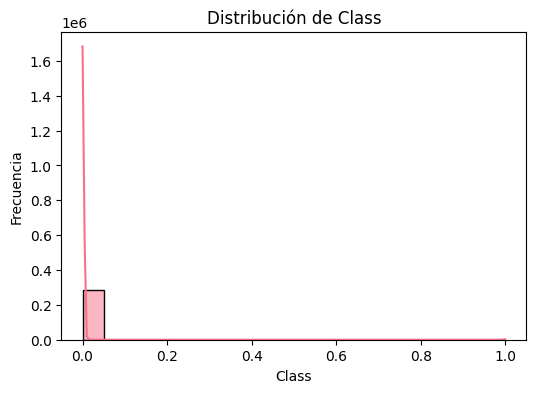

In [13]:
# Histograma + Densidad

columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns

for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

In [14]:
# Sesgo de las variables

columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
sesgo = df[columnas_numericas].skew()

print("Sesgo por variable:")
print(sesgo.sort_values(ascending=False))

Sesgo por variable:
Class     23.997579
Amount    16.977724
V28       11.192091
V21        3.592991
V7         2.553907
V6         1.826581
V10        1.187141
V4         0.676292
V26        0.576693
V9         0.554680
V11        0.356506
V19        0.109192
V13        0.065233
Time      -0.035568
V22       -0.213258
V18       -0.259880
V15       -0.308423
V25       -0.415793
V24       -0.552499
V16       -1.100966
V27       -1.170209
V14       -1.995176
V20       -2.037155
V3        -2.240155
V12       -2.278401
V5        -2.425901
V1        -3.280667
V17       -3.844914
V2        -4.624866
V23       -5.875140
V8        -8.521944
dtype: float64


In [15]:
# Clasificar tipo de distribución
clasificacion = {}

for col in columnas_numericas:
    skew = df[col].skew()

    if skew > 1:
        tipo = "Altamente sesgada a la derecha"
    elif skew > 0.5:
        tipo = "Moderadamente sesgada a la derecha"
    elif skew < -1:
        tipo = "Altamente sesgada a la izquierda"
    elif skew < -0.5:
        tipo = "Moderadamente sesgada a la izquierda"
    else:
        tipo = "Aproximadamente normal"

    clasificacion[col] = tipo

print("Clasificación de distribuciones:")
for k, v in clasificacion.items():
    print(f"{k}: {v}")

Clasificación de distribuciones:
Time: Aproximadamente normal
V1: Altamente sesgada a la izquierda
V2: Altamente sesgada a la izquierda
V3: Altamente sesgada a la izquierda
V4: Moderadamente sesgada a la derecha
V5: Altamente sesgada a la izquierda
V6: Altamente sesgada a la derecha
V7: Altamente sesgada a la derecha
V8: Altamente sesgada a la izquierda
V9: Moderadamente sesgada a la derecha
V10: Altamente sesgada a la derecha
V11: Aproximadamente normal
V12: Altamente sesgada a la izquierda
V13: Aproximadamente normal
V14: Altamente sesgada a la izquierda
V15: Aproximadamente normal
V16: Altamente sesgada a la izquierda
V17: Altamente sesgada a la izquierda
V18: Aproximadamente normal
V19: Aproximadamente normal
V20: Altamente sesgada a la izquierda
V21: Altamente sesgada a la derecha
V22: Aproximadamente normal
V23: Altamente sesgada a la izquierda
V24: Moderadamente sesgada a la izquierda
V25: Aproximadamente normal
V26: Moderadamente sesgada a la derecha
V27: Altamente sesgada a la

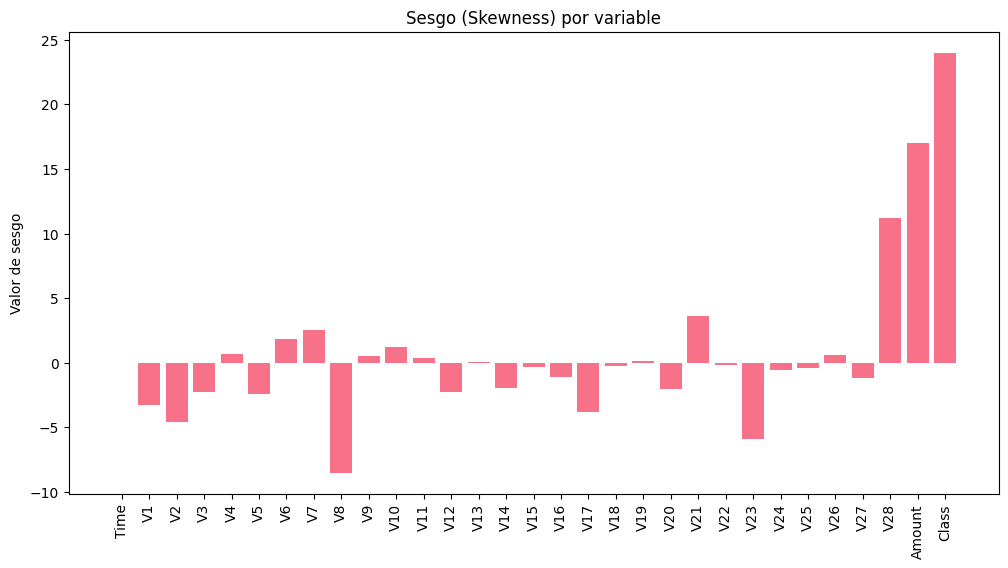

In [16]:
#Sesgo por variable
plt.figure(figsize=(12,6))

plt.bar(sesgo.index, sesgo.values)
plt.xticks(rotation=90)
plt.title("Sesgo (Skewness) por variable")
plt.ylabel("Valor de sesgo")

plt.show()

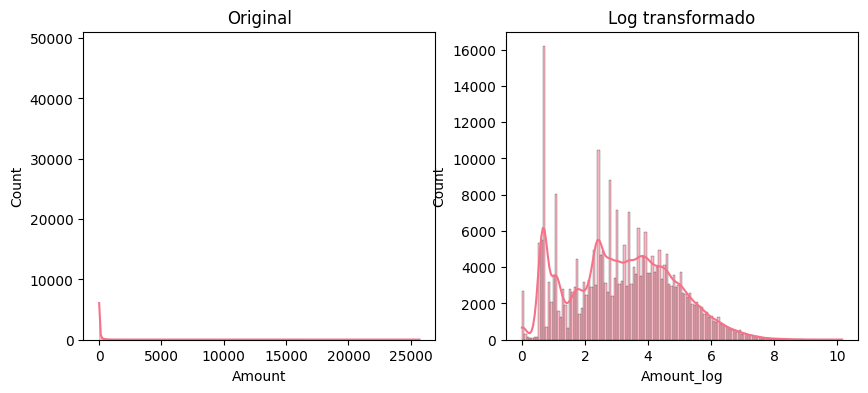

In [17]:
#Transformación
#1. logarítmica
df['Amount_log'] = np.log1p(df['Amount'])

# Graficar antes vs después
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['Amount'], kde=True)
plt.title("Original")

plt.subplot(1,2,2)
sns.histplot(df['Amount_log'], kde=True)
plt.title("Log transformado")

plt.show()

In [18]:
#2. Estandarización
scaler = StandardScaler()
df[columnas_numericas] = scaler.fit_transform(df[columnas_numericas])
print (df[columnas_numericas])

            Time        V1        V2        V3        V4        V5        V6  \
0      -1.996583 -0.694242 -0.044075  1.672773  0.973366 -0.245117  0.347068   
1      -1.996583  0.608496  0.161176  0.109797  0.316523  0.043483 -0.061820   
2      -1.996562 -0.693500 -0.811578  1.169468  0.268231 -0.364572  1.351454   
3      -1.996562 -0.493325 -0.112169  1.182516 -0.609727 -0.007469  0.936150   
4      -1.996541 -0.591330  0.531541  1.021412  0.284655 -0.295015  0.071999   
...          ...       ...       ...       ...       ...       ...       ...   
284802  1.641931 -6.065842  6.099286 -6.486245 -1.459641 -3.886611 -1.956690   
284803  1.641952 -0.374121 -0.033356  1.342145 -0.521651  0.629040  0.794446   
284804  1.641974  0.980024 -0.182434 -2.143205 -0.393984  1.905833  2.275262   
284805  1.641974 -0.122755  0.321250  0.463320  0.487192 -0.273836  0.468155   
284806  1.642058 -0.272331 -0.114899  0.463866 -0.357570 -0.009089 -0.487602   

              V7        V8        V9   

In [19]:
#3. Escalado robusto
scaler = RobustScaler()
df[columnas_numericas] = scaler.fit_transform(df[columnas_numericas])
print (df[columnas_numericas])

            Time        V1        V2        V3        V4        V5        V6  \
0      -0.994983 -0.616237 -0.098602  1.228905  0.878152 -0.217859  0.631245   
1      -0.994983  0.524929  0.143100 -0.006970  0.293974  0.087726  0.164395   
2      -0.994972 -0.615587 -1.002407  0.830932  0.251024 -0.344345  1.778007   
3      -0.994972 -0.440239 -0.178789  0.841250 -0.529808  0.033775  1.303832   
4      -0.994960 -0.526089  0.579239  0.713861  0.265632 -0.270695  0.317183   
...          ...       ...       ...       ...       ...       ...       ...   
284802  1.034951 -5.321622  7.135767 -5.222589 -1.285699 -4.073679 -1.999082   
284803  1.034963 -0.335820 -0.085979  0.967471 -0.451476  0.707747  1.142041   
284804  1.034975  0.850377 -0.261532 -1.788463 -0.337932  2.059687  2.832770   
284805  1.034975 -0.115629  0.331602  0.272567  0.445763 -0.248270  0.769496   
284806  1.035022 -0.246654 -0.182004  0.272998 -0.305547  0.032059 -0.321743   

              V7         V8        V9  

* 2.4 Análisis univariado


* 2.5 Analísis multivalorado


* 2.6 Relaciones entre variables


* 2.7 Construcción de hipótesis iniciales


* 2.8 Visualizaciones clave


* 2.9 Insghts principales